## Imports

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from feature.selector import Selective, SelectionMethod
import seaborn as sns
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_val_predict, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn import metrics
from sklearn.metrics import roc_curve, auc
import shap
from lime.lime_tabular import LimeTabularExplainer
from itertools import cycle

In [2]:
def numeric_columns(df):
    numeric_cols = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
    return numeric_cols
# Load dataset
df = pd.read_csv("15 features - no imp.csv")

# Use function to extract numeric columns
numeric_cols = numeric_columns(df)

# Create a copy of the DataFrame
df_numeric = df[numeric_cols].copy()

# Now you can safely modify df_numeric
df_numeric['mhw_category'] = df['mhw_category']

replace_category = {
    'none': 0,
    'Moderate': 1,
    'Strong': 2,
    'Severe': 3
}
df_numeric['mhw_category'] = df['mhw_category'].replace(replace_category)

print(df_numeric['mhw_category'].value_counts())

# Shuffle the DataFrame
shuffled_df_numeric = shuffle(df_numeric, random_state=42)

# Separate features (X) and labels (y) after shuffling
X = shuffled_df_numeric.drop(['mhw_category'], axis=1)
y = shuffled_df_numeric['mhw_category']
X.shape, y.shape

mhw_category
1    605
2    185
3     31
Name: count, dtype: int64


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_11840\2797522876.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric['mhw_category'] = df['mhw_category'].replace(replace_category)


((821, 15), (821,))

cross validation scores: [0.98181818 0.97560976 0.97560976 0.99390244 0.95731707]
0.9769 accuracy with a standard deviation of 0.0118
Accuracy: 97.98%
[[181   1   0]
 [  4  52   0]
 [  0   0   9]]
              precision    recall  f1-score   support

           1       0.98      0.99      0.99       182
           2       0.98      0.93      0.95        56
           3       1.00      1.00      1.00         9

    accuracy                           0.98       247
   macro avg       0.99      0.97      0.98       247
weighted avg       0.98      0.98      0.98       247



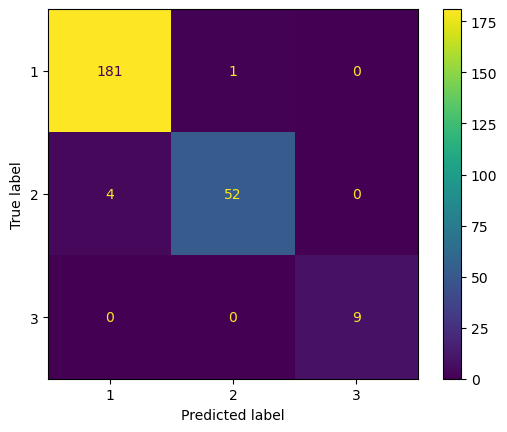

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify = y, test_size=0.3, random_state=0)

X_train.shape, y_train.shape
X_test.shape, y_test.shape

forest = RandomForestClassifier(class_weight = 'balanced', random_state=0)
forest.fit(X_train, y_train)

cross_val_scores = cross_val_score(forest, X, y, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = forest.predict(X_test)
prob_pred = forest.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test)

print(classification_report(y_test, y_pred))

In [6]:
param_grid = [
     {'min_samples_split': [2, 5, 10, 15],
     'min_samples_leaf': [1, 5, 10, 15],
     'max_features': [None, 'log2', 'sqrt'],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 10]
}]

grid = GridSearchCV(forest, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
the best score was 0.9738825324180016
the best parameters were {'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.657919,0.058326,0.015578,0.003705,balanced,gini,None,None,1,2,"{'class_weight': 'balanced', 'criterion': 'gin...",0.973913,0.973913,0.956522,0.921739,0.982456,0.961709,0.021692,108
1,0.677881,0.035936,0.020640,0.006691,balanced,gini,None,None,1,5,"{'class_weight': 'balanced', 'criterion': 'gin...",0.973913,0.973913,0.956522,0.930435,0.982456,0.963448,0.018537,86
2,0.652774,0.036649,0.016992,0.001373,balanced,gini,None,None,1,10,"{'class_weight': 'balanced', 'criterion': 'gin...",0.973913,0.956522,0.921739,0.921739,0.947368,0.944256,0.020267,323
3,0.648157,0.044136,0.016310,0.005144,balanced,gini,None,None,1,15,"{'class_weight': 'balanced', 'criterion': 'gin...",0.965217,0.947826,0.913043,0.921739,0.938596,0.937285,0.018560,392
4,0.654125,0.040867,0.020026,0.002762,balanced,gini,None,None,5,2,"{'class_weight': 'balanced', 'criterion': 'gin...",0.973913,0.939130,0.904348,0.913043,0.929825,0.932052,0.024233,455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,0.161790,0.003959,0.008995,0.006091,None,entropy,10,sqrt,10,15,"{'class_weight': None, 'criterion': 'entropy',...",0.956522,0.982609,0.939130,0.921739,0.929825,0.945965,0.021672,289
1148,0.163587,0.013715,0.004751,0.006309,None,entropy,10,sqrt,15,2,"{'class_weight': None, 'criterion': 'entropy',...",0.913043,0.982609,0.939130,0.921739,0.929825,0.937269,0.024260,394
1149,0.161926,0.010826,0.008781,0.008189,None,entropy,10,sqrt,15,5,"{'class_weight': None, 'criterion': 'entropy',...",0.913043,0.982609,0.939130,0.921739,0.929825,0.937269,0.024260,394
1150,0.153092,0.007645,0.004764,0.006333,None,entropy,10,sqrt,15,10,"{'class_weight': None, 'criterion': 'entropy',...",0.913043,0.982609,0.939130,0.921739,0.929825,0.937269,0.024260,394


cross validation scores: [0.98181818 0.98170732 0.97560976 0.99390244 0.96341463]
0.9793 accuracy with a standard deviation of 0.0099
Accuracy: 97.98%
[[181   1   0]
 [  4  52   0]
 [  0   0   9]]
              precision    recall  f1-score   support

           1       0.98      0.99      0.99       182
           2       0.98      0.93      0.95        56
           3       1.00      1.00      1.00         9

    accuracy                           0.98       247
   macro avg       0.99      0.97      0.98       247
weighted avg       0.98      0.98      0.98       247



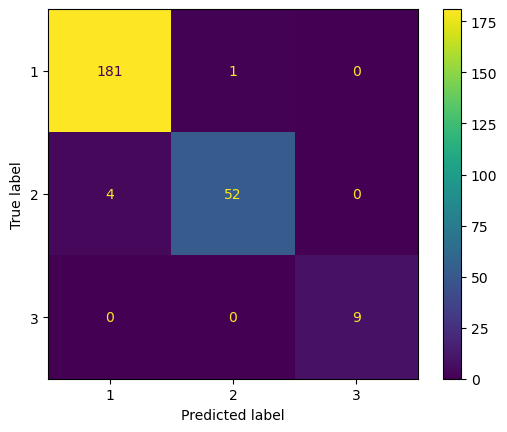

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify = y, test_size=0.3, random_state=0)

X_train.shape, y_train.shape
X_test.shape, y_test.shape

forest = RandomForestClassifier(class_weight = None, max_features = 'log2', random_state=0)
forest.fit(X_train, y_train)

cross_val_scores = cross_val_score(forest, X, y, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = forest.predict(X_test)
prob_pred = forest.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test)

print(classification_report(y_test, y_pred))